In [1]:
# Data handling
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# Machine learning & text processing
import tensorflow as tf
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences
from tensorflow.keras.models import Model
from tensorflow.keras.layers import Embedding, Bidirectional, GRU, Dense, Dropout, Input, GlobalAveragePooling1D
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, classification_report

# Text preprocessing
import re
import string
import nltk
from nltk.corpus import stopwords
# Download stopwords for text cleaning
nltk.download("stopwords")
stop_words = set(stopwords.words("english"))


C:\Users\isaac\anaconda3\envs\py310\lib\site-packages\h5py\__init__.py:36: UserWarning: h5py is running against HDF5 1.14.6 when it was built against 1.14.5, this may cause problems
  _warn(("h5py is running against HDF5 {0} when it was built against {1}, "
[nltk_data] Downloading package stopwords to
[nltk_data]     C:\Users\isaac\AppData\Roaming\nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


In [2]:
# Load datasets
true_df = pd.read_csv("true_cleaned.csv")
fake_df = pd.read_csv("fake_cleaned.csv")

# Add a label column: 1 for real news, 0 for fake news
true_df["label"] = 1
fake_df["label"] = 0

# Combine both datasets
data = pd.concat([true_df, fake_df], ignore_index=True)

# Shuffle dataset
data = data.sample(frac=1).reset_index(drop=True)



In [3]:
# Define tokenizer
max_words = 50000  # Vocabulary size
max_length = 300   # Maximum words per article

tokenizer = Tokenizer(num_words=max_words, oov_token="<OOV>")
tokenizer.fit_on_texts(data["text"])
sequences = tokenizer.texts_to_sequences(data["text"])

# Pad sequences
X = pad_sequences(sequences, maxlen=max_length, padding="post", truncating="post")

# Labels (0 = Real, 1 = Fake)
y = data["label"].values


In [4]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)


In [8]:
import numpy as np
import gensim
from gensim.models import KeyedVectors

# Load the fastText embeddings (text format)
fasttext_path = "wiki-news-300d-1M.vec"

word_vectors = gensim.models.KeyedVectors.load_word2vec_format(fasttext_path, binary=False)
print(f"Found {len(word_vectors.key_to_index)} word vectors.")

Found 999994 word vectors.


In [10]:
vocab_size = len(tokenizer.word_index) + 1
embedding_matrix = np.zeros((vocab_size, 300))  # 300-dimensional fastText embeddings

for word, index in tokenizer.word_index.items():
    if word in word_vectors:
        embedding_matrix[index] = word_vectors[word]

print(f"Embedding matrix shape: {embedding_matrix.shape}")


Embedding matrix shape: (138023, 300)


In [11]:
from tensorflow.keras.layers import Input, Embedding, Bidirectional, GRU, Dense, Dropout, Attention, GlobalAveragePooling1D
from tensorflow.keras.models import Model

# Define the input layer
input_layer = Input(shape=(max_length,))

embedding_layer = Embedding(input_dim=max_words, 
                            output_dim=128, 
                            input_length=max_length)(input_layer)


# Bi-GRU Layer
bi_gru = Bidirectional(GRU(128, return_sequences=True))(embedding_layer)

# Word-Level Attention
attention_query = Dense(256, activation='tanh')(bi_gru)
attention_output = Attention()([attention_query, bi_gru])
sentence_vector = GlobalAveragePooling1D()(attention_output)

# Multi-Layer Perceptron (MLP)
dense1 = Dense(512, activation='relu')(sentence_vector)
dropout1 = Dropout(0.2)(dense1)
dense2 = Dense(256, activation='relu')(dropout1)
dropout2 = Dropout(0.2)(dense2)
dense3 = Dense(128, activation='relu')(dropout2)
dropout3 = Dropout(0.2)(dense3)
dense4 = Dense(50, activation='relu')(dropout3)
dropout4 = Dropout(0.2)(dense4)
dense5 = Dense(10, activation='relu')(dropout4)

# Output Layer
output_layer = Dense(1, activation='sigmoid')(dense5)

# Compile Model
model = Model(inputs=input_layer, outputs=output_layer)
model.compile(loss='binary_crossentropy', optimizer='adam', metrics=['accuracy'])

model.summary()


Model: "model"
__________________________________________________________________________________________________
 Layer (type)                   Output Shape         Param #     Connected to                     
 input_1 (InputLayer)           [(None, 300)]        0           []                               
                                                                                                  
 embedding (Embedding)          (None, 300, 128)     6400000     ['input_1[0][0]']                
                                                                                                  
 bidirectional (Bidirectional)  (None, 300, 256)     198144      ['embedding[0][0]']              
                                                                                                  
 dense (Dense)                  (None, 300, 256)     65792       ['bidirectional[0][0]']          
                                                                                              

In [12]:
from tensorflow.keras.callbacks import EarlyStopping
early_stopping = EarlyStopping(monitor='val_loss', patience=3, restore_best_weights=True)

# Train the model
history = model.fit(X_train, y_train, 
                    epochs=10, 
                    batch_size=32, 
                    validation_data=(X_test, y_test),
                    callbacks=[early_stopping])


# history = model.fit(X_train, y_train, epochs=5, batch_size=64, validation_data=(X_test, y_test))
y_pred = (model.predict(X_test) > 0.5).astype("int32")

# Print evaluation results
print("Accuracy:", accuracy_score(y_test, y_pred))
print(classification_report(y_test, y_pred))

Epoch 1/10
1102/1102 [==============================] - 39s 31ms/step - loss: 0.0554 - accuracy: 0.9745 - val_loss: 0.0105 - val_accuracy: 0.9982
Epoch 2/10
1102/1102 [==============================] - 34s 31ms/step - loss: 0.0087 - accuracy: 0.9988 - val_loss: 0.0049 - val_accuracy: 0.9989
Epoch 3/10
1102/1102 [==============================] - 34s 31ms/step - loss: 0.0046 - accuracy: 0.9993 - val_loss: 0.0026 - val_accuracy: 0.9994
Epoch 4/10
1102/1102 [==============================] - 33s 30ms/step - loss: 0.0025 - accuracy: 0.9997 - val_loss: 0.0087 - val_accuracy: 0.9980
Epoch 5/10
1102/1102 [==============================] - 34s 31ms/step - loss: 0.0020 - accuracy: 0.9993 - val_loss: 0.0039 - val_accuracy: 0.9985
Epoch 6/10
276/276 [==============================] - 4s 12ms/step
Accuracy: 0.9994325919201089
              precision    recall  f1-score   support

           0       1.00      1.00      1.00      4570
           1       1.00      1.00      1.00      4242

    accura

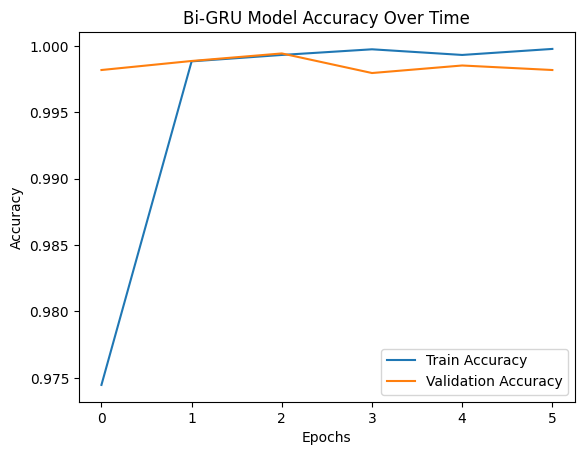

In [13]:
plt.plot(history.history['accuracy'], label='Train Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.title('Bi-GRU Model Accuracy Over Time')
plt.legend()
plt.show()


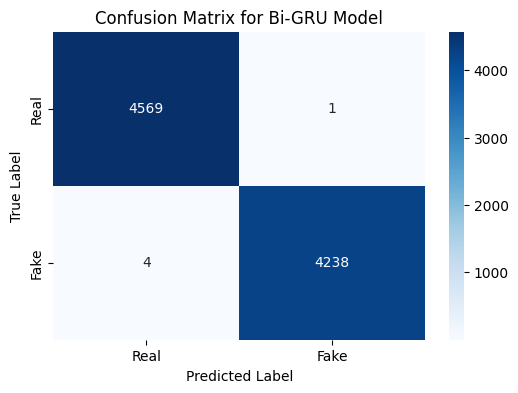

In [14]:
from sklearn.metrics import confusion_matrix
import seaborn as sns

cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(6,4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=['Real', 'Fake'], yticklabels=['Real', 'Fake'])
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.title('Confusion Matrix for Bi-GRU Model')
plt.show()


In [15]:
model.save("bigru_fake_news_model_redo.h5")

In [16]:
model.save("bigru_fake_news_redo.keras")
